## Implementing Workflows pattern With LangGraph

In [1]:
# Required Libraries
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, StateGraph
import os
from dotenv import load_dotenv
load_dotenv()

c:\Users\HP\.virtualenvs\Intro_To_Rag-n9prH0y5\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
def print_workflow_info(workflow, app=None):
    """Print Comprehensive information about a LangGraph Workflow, including its states, transitions, and any associated metadata."""
    print("Workflow Information:")
    print(f"Nodes: {list(workflow.nodes)}")
    print(f"Edges: {workflow.edges}")
    try:
        finish_points = workflow.finish_points
        print(f"Finish Points: {finish_points}")
    except:
        try:
            # alternative approach to get finish points
            print(f"Finish Points: {workflow._finish_points}")
        except:
            print("Finish Points: Not available")
    if app:
        print("\n Workflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

        

In [3]:
llm = ChatGoogleGenerativeAI(api_key=os.getenv("GOOGLE_API_KEY"),
    model="gemini-2.5-flash")

### Prompt Chaining

In this workflow design pattern where complex tasks are decomposed into a sequence of llm calls. Each step depends on the output of the previous ones, allowing for step-by-step refinement or evolution of the data being processed.

In [4]:
# Prompt Chaining - Job Application Assistant
class ChainState(TypedDict):
    """A TypedDict representing the state of the job application assistant workflow."""
    resume_summary: str
    cover_letter: str
    job_description: str
    

<b>Resume Summary Agent

In [5]:
def generate_resume_summary(state: ChainState) -> ChainState:
    """Generate a summary of the resume using the provided state."""
    prompt = f"""
You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

Job Description:
{state['job_description']}
"""
    summary = llm.invoke(prompt)
    return {**state, "resume_summary": summary.content}

<b>Generate Cover Letter Agent

In [6]:
def generate_conver_letter(state: ChainState) -> ChainState:
    """Generate a cover letter based on the resume summary and job description."""
    prompt = f"""
You're a cover letter assistant. Create a compelling cover letter for the following job description, incorporating the key qualifications from the resume summary.

Job Description:
{state['job_description']}

Resume Summary:
{state['resume_summary']}
"""
    cover_letter = llm.invoke(prompt)
    return {**state, "cover_letter": cover_letter.content}

<b>LangGraph Workflow

In [7]:
workflow = StateGraph(ChainState )

In [8]:
workflow.add_node("generate_resume_summary", generate_resume_summary )
workflow.add_node("generate_cover_letter", generate_conver_letter )

workflow.set_entry_point("generate_resume_summary")

workflow.add_edge("generate_resume_summary", "generate_cover_letter")

workflow.set_finish_point("generate_cover_letter")

workflow = workflow.compile()

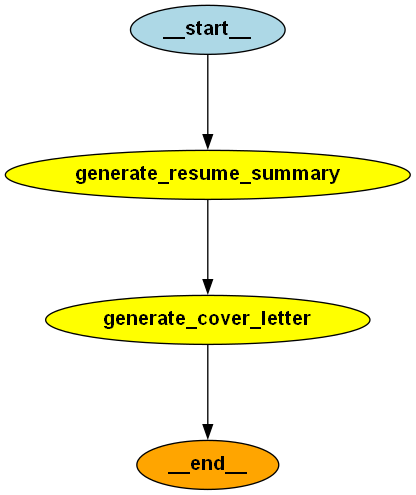

In [9]:
from IPython.display import display, Image

display(Image(workflow.get_graph().draw_png()))

In [11]:
input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = workflow.invoke(input_state)

In [12]:
result['resume_summary']

'Here\'s a resume summary from the perspective of a strong applicant:\n\n"Highly skilled Data Scientist with extensive experience in machine learning and natural language processing (NLP), proficiently leveraging Python. Proven track record of managing and analyzing large datasets, coupled with a strong ability to successfully deploy and operationalize machine learning models into production environments."'

## WorkFlow Pattern: Routing

Routing is a pattern where an LLM classifies or interprets incoming input and then routes it to the appropriate sub-process or agent.

In [13]:
class RouterState(TypedDict):
    """A TypedDict representing the state of the router workflow."""
    user_input: str
    task_type: str
    output: str

In [14]:
class Router(BaseModel):
    role: str = Field(..., description="Decide whether the user wants to summarize a passage  ouput 'summarize'  or translate text into French oupput translate.")
llm_router=llm.bind_tools([Router])

In [15]:
def router_node(state: RouterState) -> RouterState:
    """Route the user input to the appropriate task based on the task type."""
    routing_prompt = f"""
    You are an AI task classifier.
    
    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into French
    
    Respond with just one word: 'summarize' or 'translate'.
    
    User Input: "{state['user_input']}"
    """

    response = llm_router.invoke(routing_prompt)

    return {**state, "task_type": response.tool_calls[0]['args']['role']}

In [16]:
def router(state: RouterState) -> str:
    return state['task_type']

In [17]:
def summarize_node(state: RouterState) -> RouterState:
    """Summarize the user input."""
    prompt = f"""
    You are an AI summarizer.
    
    Summarize the following text:
    
    "{state['user_input']}"
    """
    summary = llm.invoke(prompt)
    return {**state,"task_type":"summarize",  "output": summary.content}

In [18]:
def translate_node(state: RouterState) -> RouterState:
    """Translate the user input into French."""
    prompt = f"""
    You are an AI translator.
    
    Translate the following text into French:
    
    "{state['user_input']}"
    """
    translation = llm.invoke(prompt)
    return {**state,"task_type":"translate",  "output": translation.content}

In [20]:
workflow = StateGraph(RouterState)

workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)
workflow.set_entry_point("router")
workflow.add_conditional_edges("router", router, {
    "summarize":"summarize",
    "translate":"translate"
})

workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")

app = workflow.compile()


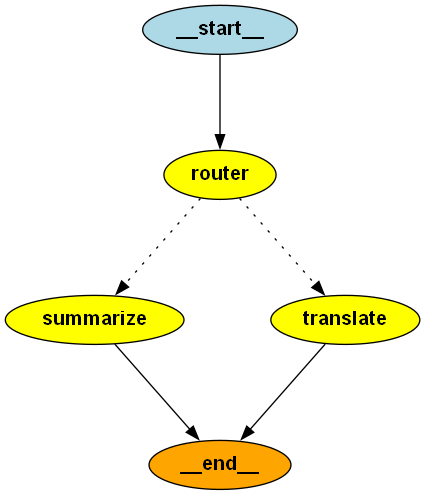

In [21]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_png()))

In [22]:
input_text = {
        "user_input": "Can you translate this sentence: I love programming?"
    }

result = app.invoke(input_text)

In [23]:
print(result[ 'output'])
print(result['task_type'])

Pouvez-vous traduire cette phrase : J'aime la programmation ?
translate


## WorkFlow Pattern: Parallelization

Parallelization is a pattern where multiple tasks are executed at the same time instead of one after the another.

In [24]:
# Use Case: Multi-Lingual Translation 
class State(TypedDict):
    """A TypedDict representing the state of the multi-lingual translation workflow."""
    text: str
    french: str
    spanish: str
    japanese: str
    combined_output: str

In [37]:
def translate_french(state: State) -> State:
    """Translate the input text into French."""
    prompt = f"""
    You are an AI translator.
    
    Translate the following text into French:
    
    "{state['text']}"
    """
    translation = llm.invoke(prompt)
    return {"french": translation.content.strip()}

In [38]:
def translate_spanish(state: State) -> State:
    """Translate the input text into Spanish."""
    prompt = f"""
    You are an AI translator.
    
    Translate the following text into Spanish:
    
    "{state['text']}"
    """
    translation = llm.invoke(prompt)
    return {"spanish": translation.content.strip()}

In [ ]:
def translate_japanese(state: State) -> State:
    """Translate the input text into Japanese."""
    prompt = f"""
    You are an AI translator.
    
    Translate the following text into Japanese:
    
    "{state['text']}"
    """
    translation = llm.invoke(prompt)
    return {"japanese": translation.content.strip()}


In [40]:
def aggregator(state: State) -> dict:
    combined = f"Original Text: {state['text']}\n\n"
    combined += f"French: {state['french']}\n\n"
    combined += f"Spanish: {state['spanish']}\n\n"
    combined += f"Japanese: {state['japanese']}\n"
    return {"combined_output": combined}

In [41]:
graph = StateGraph(State)
graph.add_node("translate_french", translate_french)
graph.add_node("translate_spanish", translate_spanish)
graph.add_node("translate_japanese", translate_japanese)
graph.add_node("aggregator", aggregator)

graph.add_edge(START, "translate_french")
graph.add_edge(START, "translate_spanish")
graph.add_edge(START, "translate_japanese")

graph.add_edge("translate_french", "aggregator")
graph.add_edge("translate_spanish", "aggregator")
graph.add_edge("translate_japanese", "aggregator")

graph.add_edge("aggregator", END)

app = graph.compile()

In [42]:
input_text = {
        "text": "Good morning! I hope you have a wonderful day."
}

result = app.invoke(input_text)

In [43]:
result

{'text': 'Good morning! I hope you have a wonderful day.',
 'french': "Bonjour ! J'espère que vous passez une excellente journée.",
 'spanish': '¡Buenos días! Espero que tengas un día maravilloso.',
 'japanese': 'おはようございます！良い一日をお過ごしください。',
 'combined_output': "Original Text: Good morning! I hope you have a wonderful day.\n\nFrench: Bonjour ! J'espère que vous passez une excellente journée.\n\nSpanish: ¡Buenos días! Espero que tengas un día maravilloso.\n\nJapanese: おはようございます！良い一日をお過ごしください。\n"}